# Линейная регрессия

### Задача 1: Синтетическая регрессия «на пальцах»

**Условие:** Сгенерировать вручную массив данных. Пусть $X$ — это числа от 1 до 10. А $y$ вычисляется по формуле $y = 3X + 5 + \epsilon$, где $\epsilon$ — случайный шум (используйте `numpy.random.normal`).

**Что нужно сделать:**

1. Построить scatter-plot (диаграмму рассеяния) этих точек.
2. Не используя `scikit-learn`, написать функцию на чистом NumPy, которая вычисляет веса $w_1$ и $w_0$ по формуле нормального уравнения МНК: $w = (X^T X)^{-1} X^T y$.
3. Сравнить полученные коэффициенты с заложенными (3 и 5). Нарисовать полученную прямую линию поверх точек.

Коэффициент k: 2.01
Свободный член b: 0.02999999999999861


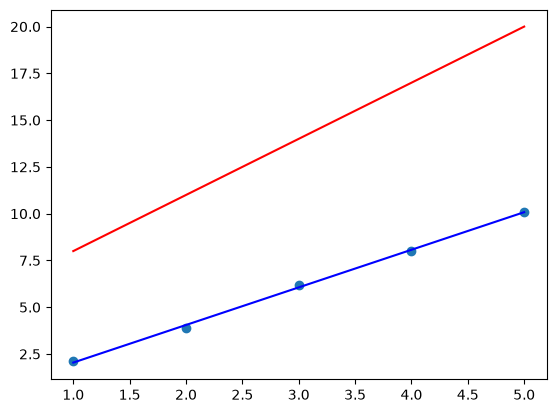

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5])
y = np.array([2.1, 3.9, 6.2, 8.0, 10.1])

Y = 3 * x + 5

# Нахождение коэффициентов k и b для прямой y = kx + b (степень 1)
k, b = np.polyfit(x, y, 1)

Y_new = k * x + b

print(f"Коэффициент k: {k}")
print(f"Свободный член b: {b}")

plt.scatter(x, y)
plt.plot(x, Y, color='red')
plt.plot(x, Y_new, color='blue')
plt.show()


### Задача 2: Предсказание медицинских расходов (Работа с реальными данными)

**Датасет:** Скачать с Kaggle датасет **"Medical Cost Personal Datasets"**. Целевая переменная — `charges` (медицинские расходы).

**Что нужно сделать:**

1. Провести анализ: как расходы зависят от возраста (`age`), индекса массы тела (`bmi`) и курения (`smoker`).
2. Закодировать категориальные признаки: `smoker` (yes/no $\rightarrow$ 1/0), `sex`, `region` (использовать `pd.get_dummies` или `OneHotEncoder`).
3. Разделить выборку на Train и Test (80/20).
4. Обучить `LinearRegression` из `sklearn`.
5. Посчитать метрики **MSE**, **MAE** и **$R^2$** (коэффициент детерминации) на тестовой выборке. Написать вывод, насколько хороша модель.
6. Посмотреть на коэффициенты обученной модели (`model.coef_`). Какой признак вносит самый большой вклад в стоимость страховки?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("insurance.csv")

df = df.dropna()
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [3]:
# применяем one-hot encoding
df_encoded = pd.get_dummies(df, dtype=int)

print(df_encoded)

      age     bmi  children      charges  sex_female  sex_male  smoker_no  \
0      19  27.900         0  16884.92400           1         0          0   
1      18  33.770         1   1725.55230           0         1          1   
2      28  33.000         3   4449.46200           0         1          1   
3      33  22.705         0  21984.47061           0         1          1   
4      32  28.880         0   3866.85520           0         1          1   
...   ...     ...       ...          ...         ...       ...        ...   
1333   50  30.970         3  10600.54830           0         1          1   
1334   18  31.920         0   2205.98080           1         0          1   
1335   18  36.850         0   1629.83350           1         0          1   
1336   21  25.800         0   2007.94500           1         0          1   
1337   61  29.070         0  29141.36030           1         0          0   

      smoker_yes  region_northeast  region_northwest  region_southeast  \
0

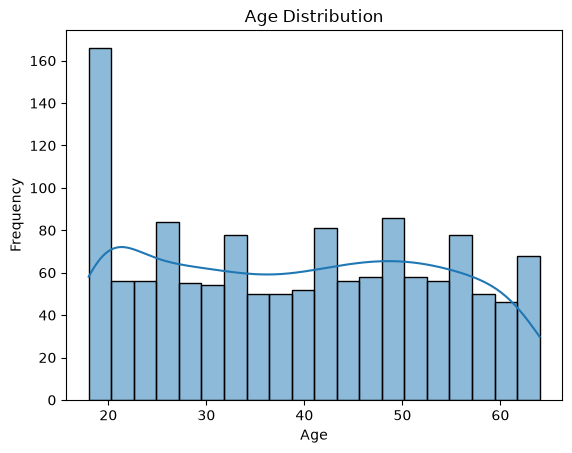

In [4]:
sns.histplot(df_encoded["age"], bins = 20, kde = True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<Axes: >

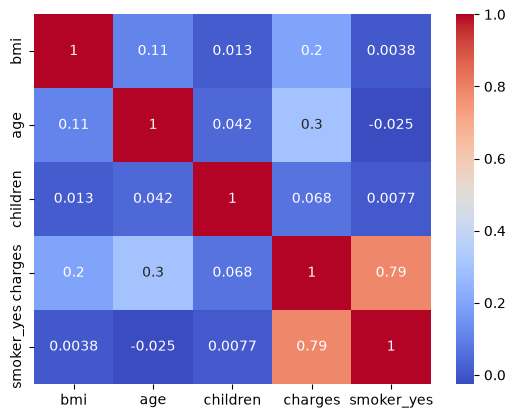

In [5]:
corr = df_encoded[["bmi", "age", "children", "charges", "smoker_yes"]].corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm")

In [6]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1070, 11)
Размер тестовой выборки: (268, 11)


In [8]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean absolute error: {mae:.4f}")

R-squared: 0.8666
Mean squared error: 20712805.9879
Mean absolute error: 2729.5001


In [11]:
new_data = pd.DataFrame({
    "age": [30],
    "bmi": [25.0],
    "children": [1],
    "sex_female": [1],
    "sex_male": [0],
    "smoker_yes": [1],
    "smoker_no": [0],
    "region_northeast": [0],
    "region_northwest": [1],
    "region_southeast": [0],
    "region_southwest": [0]
})

new_data = new_data[X_train.columns]

new_data_poly = poly.transform(new_data)

new_data_scaled = scaler.transform(new_data_poly)

predicted_charges = model.predict(new_data_scaled)
print(f"Предсказанная цена с полиномами: ${predicted_charges[0]:,.2f}")

Предсказанная цена с полиномами: $20,728.36


### Задача 3: Борьба с мультиколлинеарностью и отбор признаков (Ridge vs Lasso)

**Датасет:** Взять встроенный в sklearn датасет стоимости жилья в Калифорнии (`sklearn.datasets.fetch_california_housing`).

**Что нужно сделать:**

1. Построить матрицу корреляции признаков (`sns.heatmap(df.corr())`). Проверить, есть ли признаки, которые сильно коррелируют между собой (это называется мультиколлинеарностью и ломает обычную линейную регрессию).
2. Добавить в датасет 20 столбцов с абсолютно случайным шумом (используя `np.random.rand`), чтобы искусственно усложнить задачу.
3. Обучить три модели на Train-выборке: обычную `LinearRegression`, `Ridge` и `Lasso`.
4. Сравнить их метрику $R^2$ на Test-выборке.
5. Вывести количество ненулевых весов у каждой из трех моделей. Убедиться, что `Lasso` занулила веса у случайного шума, а обычная регрессия сошла со ума и присвоила шуму случайные веса.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

df = sklearn.datasets.fetch_california_housing(as_frame=True).frame

df = df.dropna()
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

<Axes: >

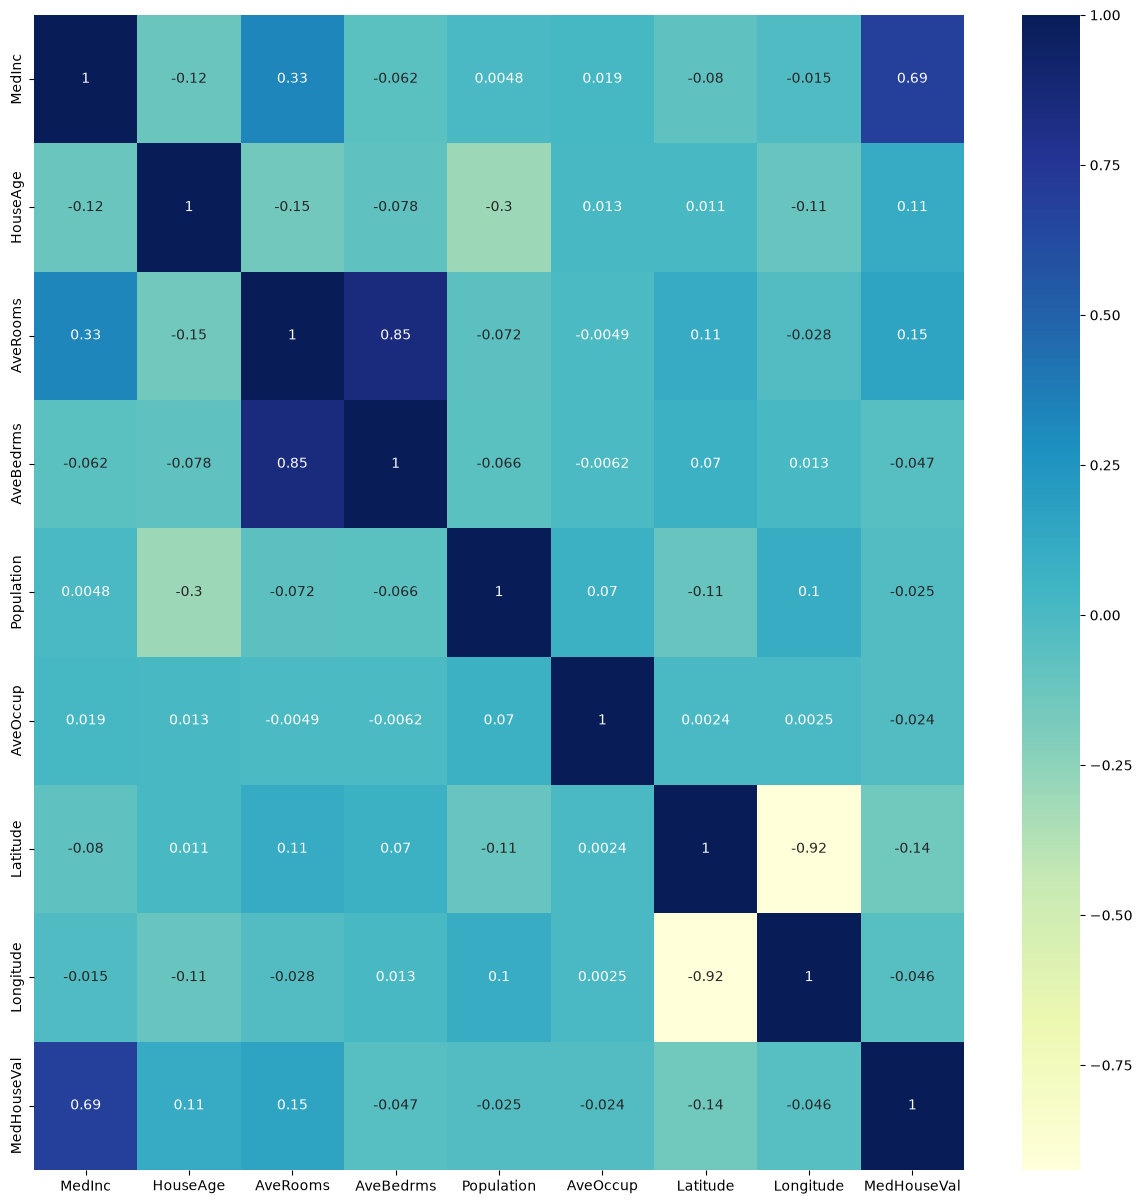

In [13]:
plt.figure(figsize= (15, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [14]:
num_noise_cols = 20
num_rows = len(df)

noise_data = np.random.normal(
    loc=0, scale=1, size=(num_rows, num_noise_cols)
)  # среднее=0, ст.отклонение=1

noise_cols = [f"noise_{i}" for i in range(1, num_noise_cols + 1)]

df_noise = pd.DataFrame(noise_data, columns=noise_cols, index=df.index)

df = pd.concat([df, df_noise], axis=1)

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal   noise_1  ...  noise_11  noise_12  noise_13  \
0    -122.23        4.526  1.235613  ... -1.611189 -0.205750  1.379999   
1    -122.22        3.585  1.629796  ...  1.485780  0.069800  1.141504   
2    -122.24        3.521 -0.638661  ...  1.257732  0.804724  0.989508   
3    -122.25        3.413  0.158375  ...  0.494623  0.140392 -0.610301   
4    -122.25        3.422  1.282849  ...  0.341865  0.852238  1.034519   

   noise_14  noise_15  noise_16  noise_17  noise_18  noise_19  noise_20  
0  1.357626 -0.323124  0

In [15]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (16512, 28)
Размер тестовой выборки: (4128, 28)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

model_lin = LinearRegression()
model_ridge = Ridge(alpha=1.0)
model_lasso = Lasso(alpha=0.1)

model_lin.fit(X_train_scaled, y_train)
model_ridge.fit(X_train_scaled, y_train)
model_lasso.fit(X_train_scaled, y_train)

y_pred_lin = model_lin.predict(X_test_scaled)
y_pred_ridge = model_ridge.predict(X_test_scaled)
y_pred_lasso = model_lasso.predict(X_test_scaled)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

r2_lin = r2_score(y_test, y_pred_lin)
print(f"R-squared (Linear): {r2_lin:.4f}")

r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"R-squared (Ridge): {r2_ridge:.4f}")

r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"R-squared (Lasso): {r2_lasso:.4f}")

mse_lin = mean_squared_error(y_test, y_pred_lin)
print(f"Mean squared error (Linear): {mse_lin:.4f}")

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Mean squared error (Ridge): {mse_ridge:.4f}")

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Mean squared error (Lasso): {mse_lasso:.4f}")

mae_lin = mean_absolute_error(y_test, y_pred_lin)
print(f"Mean absolute error (Linear): {mae_lin:.4f}")

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"Mean absolute error (Ridge): {mae_ridge:.4f}")

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"Mean absolute error (Lasso): {mae_lasso:.4f}")

R-squared (Linear): 0.5753
R-squared (Ridge): 0.5753
R-squared (Lasso): 0.4814
Mean squared error (Linear): 0.5566
Mean squared error (Ridge): 0.5565
Mean squared error (Lasso): 0.6796
Mean absolute error (Linear): 0.5343
Mean absolute error (Ridge): 0.5343
Mean absolute error (Lasso): 0.6222


In [20]:
new_data = pd.DataFrame({
    "MedInc": [7.0],
    "HouseAge": [25.0],
    "AveRooms": [3.0],
    "AveBedrms": [1.0],
    "Population": [300],
    "AveOccup": [2.5],
    "Latitude": [37.86],
    "Longitude": [-122.23]
})

for i in range(1, 21):
    new_data[f"noise_{i}"] = 0.0

new_data = new_data[X_train.columns]

new_data_scaled = scaler.transform(new_data)
predicted_charges = model_lasso.predict(new_data_scaled)
print(f"Предсказанная цена: ${predicted_charges[0]*100000:,.2f}")

Предсказанная цена: $319,356.67
